# Task 1: Burnout Prediction

In this notebook I look at several factors associated with employee burnout and try to predict whether an employee will/is experiencing burnout.

In [19]:
import sys

sys.path.append("/Users/jared.mcbride/Documents/Code Projects/SVU-AI/Unit 2: Neural Networks Basics/")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import Neurons

In [26]:
df = pd.read_csv("/Users/jared.mcbride/Documents/Code Projects/SVU-AI/Unit 2: Neural Networks Basics/synthetic_employee_burnout.csv")

df.tail()

,Name,Age,Gender,JobRole,Experience,WorkHoursPerWeek,RemoteRatio,SatisfactionLevel,StressLevel,Burnout
1995,Leo Brown,41,Female,Manager,4,63,17,3.40,4,0
1996,Alex Brown,23,Female,HR,2,39,20,4.67,9,0
1997,Nina Wang,31,Female,HR,10,39,4,4.10,4,0
1998,Kate Lee,25,Male,HR,0,40,57,2.11,4,0
1999,Lily Petrov,49,Female,Engineer,13,65,22,4.36,8,0


In [27]:
df = pd.read_csv("/Users/jared.mcbride/Documents/Code Projects/SVU-AI/Unit 2: Neural Networks Basics/synthetic_employee_burnout.csv")

del df["Name"]

df = pd.get_dummies(df, columns=["Gender", "JobRole"])

df.tail()

,Age,Experience,WorkHoursPerWeek,RemoteRatio,SatisfactionLevel,StressLevel,Burnout,Gender_Female,Gender_Male,JobRole_Analyst,JobRole_Engineer,JobRole_HR,JobRole_Manager,JobRole_Sales
1995,41,4,63,17,3.40,4,0,True,False,False,False,False,True,False
1996,23,2,39,20,4.67,9,0,True,False,False,False,True,False,False
1997,31,10,39,4,4.10,4,0,True,False,False,False,True,False,False
1998,25,0,40,57,2.11,4,0,False,True,False,False,True,False,False
1999,49,13,65,22,4.36,8,0,True,False,False,True,False,False,False


In [28]:
df = df.sample(frac = 1).reset_index(drop=True)

df.tail()

Y = df.pop("Burnout")
Y = Y.to_numpy()
Y = np.where(Y == 0, -1, 1)

X = df.to_numpy()
X

array([[26, 0, 56, ..., False, False, False],
       [49, 23, 46, ..., False, False, False],
       [29, 1, 35, ..., False, True, False],
       ...,
       [58, 14, 60, ..., False, False, True],
       [53, 19, 38, ..., False, False, False],
       [52, 23, 59, ..., True, False, False]], dtype=object)

In [23]:
np.unique(Y)

array([-1,  1])

In [24]:
X_train = X[:1400,:]
X_test  = X[1400:,:]

Y_train = Y[:1400]
Y_test  = Y[1400:]

Y_test.shape

(600,)

In [7]:
ada = Neurons.Adaline(eta = 0.000_000_1, n_epochs = 100)
ada.fit(X_train, Y_train)

ada.cost_

[420.27086280726536,
 228.6844990110287,
 224.00959424215927,
 220.03036761231493,
 216.63919032977827,
 213.74557822878552,
 211.2730498234627,
 209.15695664849713,
 207.3426498913417,
 205.78393118562082,
 204.4417435178459,
 203.28306502765872,
 202.2799742513874,
 201.40886023396823,
 200.64975505373764,
 199.98576978553245,
 199.40261786882598,
 198.8882123330011,
 198.43232543193457,
 198.02630101463978,
 197.6628114581424,
 197.33565225582723,
 197.03956842507208,
 196.7701078026683,
 196.52349706094725,
 196.29653692342612,
 196.08651360463114,
 195.89112395991037,
 195.7084122207723,
 195.53671652055831,
 195.37462369353577,
 195.22093106558043,
 195.07461415331713,
 194.9347993564469,
 194.80074086984783,
 194.67180116189823,
 194.547434466761,
 194.42717282395017,
 194.31061427081843,
 194.19741285471676,
 194.0872701832143,
 193.97992827439987,
 193.87516350615908,
 193.77278149447454,
 193.67261275712247,
 193.57450904139796,
 193.47834021327557,
 193.38399162133084,
 193.

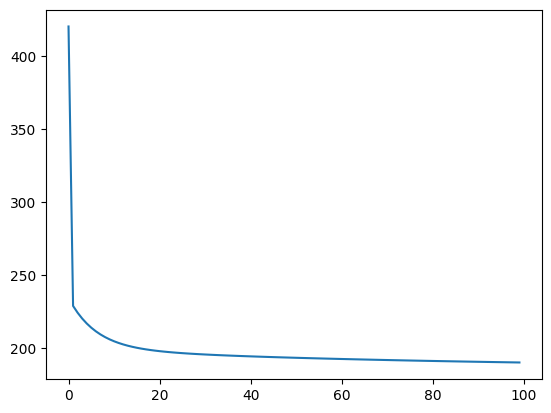

In [8]:
plt.plot(ada.cost_)

In [9]:
error_rate = np.mean(Y_test != ada.predict(X_test))
error_rate

0.058333333333333334

In [10]:
burnout_rate = sum(Y_test == 1)/sum(Y_test == -1)

burnout_rate

0.061946902654867256

## Standardize

In [30]:
mu  = X_train.mean(axis=0)
# For some reason, np.std(X_train, axis=0) gives an error here
sig = np.array([np.std(X_train[:,i]) for i in range(X_train.shape[1])])

X_train_std = (X_train - mu) / sig
X_test_std  = (X_test  - mu) / sig

array([[0.5573523564634029, 1.3991887317179168, 0.03456334606239704, ...,
        -0.4910547339890389, -0.5266614308772967, -0.4966495043659987],
       [0.11263943098251593, 0.5257193713009574, 0.37774550554718944,
        ..., 2.036432867425132, -0.5266614308772967, -0.4966495043659987],
       [-1.1325567603639675, -1.0028520094287217, 1.0641098245167742,
        ..., -0.4910547339890389, -0.5266614308772967,
        2.0134923949567383],
       ...,
       [1.3578356223289993, 0.08898469109247768, 0.20615442580479323,
        ..., -0.4910547339890389, -0.5266614308772967,
        2.0134923949567383],
       [0.7352375266557577, 1.7267397418742765, -1.681347451361565, ...,
        -0.4910547339890389, -0.5266614308772967, -0.4966495043659987],
       [0.4684097713672255, 0.7440867114051972, -0.6518009729071877, ...,
        -0.4910547339890389, -0.5266614308772967, 2.0134923949567383]],
      dtype=object)

In [12]:
adas = Neurons.Adaline(eta = 0.0001, n_epochs = 100)
adas.fit(X_train_std, Y_train)
adas.cost_

[714.7326115692371,
 564.5271181591519,
 453.41605673539664,
 371.2185878329412,
 310.4066983576748,
 265.41350117441954,
 232.12202359216047,
 207.48734790609885,
 189.25729032376134,
 175.76590196010636,
 165.7807929068271,
 158.39024122156889,
 152.9197129329793,
 148.87012610044226,
 145.8721919751827,
 143.65264418603815,
 142.009259053783,
 140.7923773673168,
 139.89123463660096,
 139.22384792869266,
 138.72953349462324,
 138.3633705032916,
 138.0921044800093,
 137.89111588272243,
 137.74217674536206,
 137.63179042435064,
 137.5499628164363,
 137.48929286456269,
 137.44429934937583,
 137.4109225509855,
 137.38615533581984,
 137.36777003896657,
 137.35411625460588,
 137.3439711157673,
 137.33642843123008,
 137.33081658951315,
 137.32663776124457,
 137.3235228712281,
 137.3211982473991,
 137.31946091662732,
 137.31816030403334,
 137.31718467479493,
 137.31645108853436,
 137.3158979555295,
 137.3154795202829,
 137.3151617729352,
 137.3149194185672,
 137.31473363034976,
 137.31459038

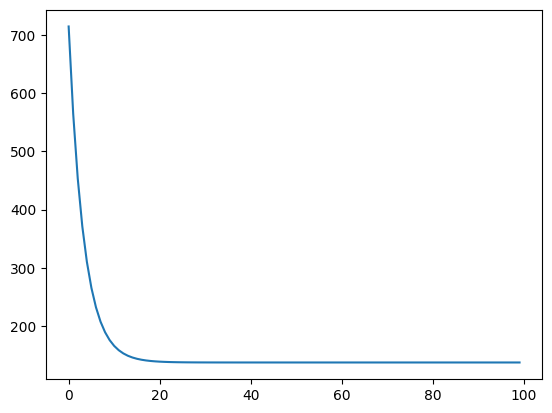

In [13]:
plt.plot(adas.cost_)

In [14]:
error_rate_std = np.mean(Y_test != adas.predict(X_test_std))
error_rate_std

0.058333333333333334

In [17]:
Y = np.where(Y == -1, 0, 1)
np.unique(Y)

np.bincount(Y)/len(Y)

array([0., 1.])

# PCA

In [34]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X)
X_reduced.shape

(2000, 3)

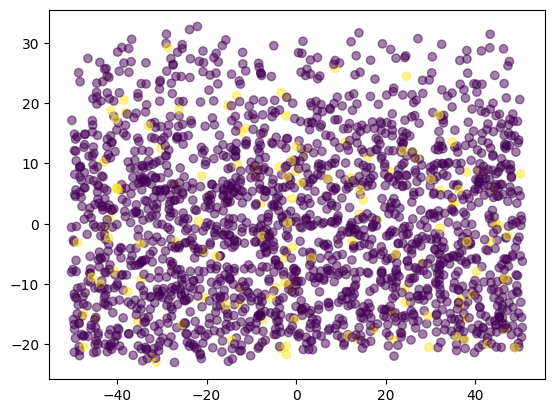

In [50]:
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=Y, cmap='viridis', alpha=0.5)

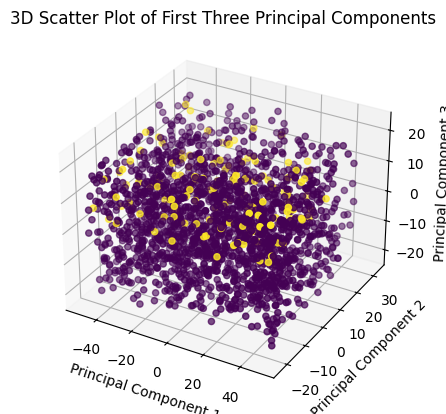

In [37]:
# Create a 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the first three principal components
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2], c=Y, marker='o')

# Set axis labels
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Show the plot
plt.title("3D Scatter Plot of First Three Principal Components")
plt.show()

In [38]:
from sklearn.linear_model import LogisticRegression

In [43]:
Y_train_m = np.where(Y_train == -1, 0, 1)
Y_test_m  = np.where(Y_test  == -1, 0, 1)

model=LogisticRegression(class_weight="balanced")
model.fit(X_train_std,Y_train_m)

LogisticRegression(class_weight='balanced')

In [44]:
error_rate_lr = np.mean(Y_test_m != model.predict(X_test_std))
error_rate_lr

0.07

In [46]:
burnout_rate = sum(Y_test == 1)/sum(Y_test == -1)
burnout_rate

0.07526881720430108

In [47]:
X_train_std.mean(axis=0)

array([-1.9183067832630382e-16, -7.486075251758198e-17,
       9.508267189468305e-17, -1.0721582352094369e-16,
       1.9666807864788486e-17, 6.637547654366115e-17,
       -2.8612033377482604e-16, 2.8612033377482604e-16,
       1.1252903371022122e-16, 2.589991713161258e-16,
       3.1538264063816054e-16, -7.470214922834981e-17,
       -6.090366306515145e-17], dtype=object)